In [104]:
import numpy as np, sys,os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.io import loadmat
import wfdb
import tarfile
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.model_selection import StratifiedKFold
from keras.preprocessing.sequence import pad_sequences
import math
import warnings
import os
import tensorflow as tf
from sklearn.metrics import accuracy_score
from sklearn.metrics import roc_auc_score
from scipy import signal
from tqdm import tqdm
import json

In [105]:
#%pip install wfdb
#%pip install tqdm

In [106]:
class OsdbLabelGenerator:
    def __init__(self, file_path, sampling_rate=25):
        self.file_path = file_path  # Path to the JSON file
        self.sampling_rate = sampling_rate  # Sampling rate (Hz)
        self.df_sensordata = None  # To store the processed DataFrame
        
    def load_data(self):
        """Load and flatten the JSON data into a DataFrame."""
        with open(self.file_path, 'r') as file:
            raw_json = json.load(file)
        
        flattened_data = []
        for attribute in raw_json:
            datapoints = attribute.get('datapoints', [])
            subType = attribute.get('subType', None)

            
            for point in datapoints:
                event_id = point.get('eventId', None)
                rawData = point.get('rawData', [])
                flattened_data.append({
                    'eventId': event_id,
                    'subType': subType,
                    'rawData': rawData
                })
        
        # Convert to DataFrame
        self.df_sensordata = pd.DataFrame(flattened_data)
        
        # Add a sequential 'Id' column
        self.df_sensordata['Id'] = range(len(self.df_sensordata))
    

    def process_data(self):
        """Process the data through all stages and return the final DataFrame."""
        # Step 1: Load the data
        self.load_data()
        # Step 6: Ensure the DataFrame is sorted by 'Id' column
        self.df_sensordata.sort_values(by='Id', inplace=True)
        self.df_sensordata.reset_index(drop=True, inplace=True)

        return self.df_sensordata

In [107]:
file_path = 'Data/osdb_3min_allSeizures.json'  # Replace with your JSON file path
osdb_processor = OsdbLabelGenerator(file_path)
df_result = osdb_processor.load_data()
df_result = osdb_processor.process_data()
df_result

,eventId,subType,rawData,Id
0,407,Other,"[1496, 1480, 1500, 1492, 1496, 1484, 1500, 149...",0
1,407,Other,"[1492, 1508, 1496, 1476, 1484, 1476, 1496, 150...",1
2,407,Other,"[1488, 1496, 1484, 1492, 1492, 1508, 1504, 148...",2
3,407,Other,"[1488, 1476, 1480, 1504, 1496, 1508, 1484, 148...",3
4,407,Other,"[1504, 1488, 1504, 1492, 1484, 1500, 1496, 149...",4
...,...,...,...,...
3944,53666,Other,"[1001.399048, 1004.223083, 1015.488037, 994.85...",3944
3945,53666,Other,"[982.698303, 987.676086, 1013.998047, 1001.670...",3945
3946,53666,Other,"[999.175659, 1009.316589, 1002.189575, 988.712...",3946
3947,53666,Other,"[1009.403809, 999.952026, 1012.031616, 999.607...",3947


In [108]:
# Group the DataFrame by eventId and count the rows for each eventId
event_counts = df_result.groupby("eventId").size()

# Filter for eventId values where the count is exactly 30
event_ids_with_length_30 = event_counts[event_counts == 30].index.tolist()

# Print the eventId values
print("Event IDs with length 30:", event_ids_with_length_30)

Event IDs with length 30: [407, 5288, 5610, 5705, 6590, 6668, 6897, 7006, 7125, 8800, 8970, 9828, 11591, 12206, 12973, 14101, 14157, 14159, 15923, 21458, 26992, 31420, 31421, 34756, 36812, 40784, 44137, 45781, 47000, 53666]


In [109]:
# List of eventIds to keep
event_ids_to_keep = [
    407, 5288, 5610, 5705, 6590, 6668, 6897, 7006, 73750, 8800, 
    8970, 9828, 11591, 12206, 12973, 14101, 14157, 14159, 15923, 
    21458, 26992, 31420, 31421, 34756, 36812, 40784, 44137, 45781, 
    47000, 53666
]

# Filter the DataFrame to keep only rows with these eventIds
filtered_df = df_result[df_result["eventId"].isin(event_ids_to_keep)]

# Display the filtered DataFrame
print(filtered_df)


      eventId subType                                            rawData    Id
0         407   Other  [1496, 1480, 1500, 1492, 1496, 1484, 1500, 149...     0
1         407   Other  [1492, 1508, 1496, 1476, 1484, 1476, 1496, 150...     1
2         407   Other  [1488, 1496, 1484, 1492, 1492, 1508, 1504, 148...     2
3         407   Other  [1488, 1476, 1480, 1504, 1496, 1508, 1484, 148...     3
4         407   Other  [1504, 1488, 1504, 1492, 1484, 1500, 1496, 149...     4
...       ...     ...                                                ...   ...
3944    53666   Other  [1001.399048, 1004.223083, 1015.488037, 994.85...  3944
3945    53666   Other  [982.698303, 987.676086, 1013.998047, 1001.670...  3945
3946    53666   Other  [999.175659, 1009.316589, 1002.189575, 988.712...  3946
3947    53666   Other  [1009.403809, 999.952026, 1012.031616, 999.607...  3947
3948    53666   Other  [1003.944214, 987.586975, 981.949097, 971.5472...  3948

[870 rows x 4 columns]


In [110]:
df = filtered_df


# Step 1: Ensure rawData contains proper lists
df['rawData'] = df['rawData'].apply(lambda x: x if isinstance(x, list) else [])

# Step 2: Aggregate rawData points for rows with the same eventId
grouped = df.groupby(["eventId", "subType"], as_index=False).agg(
    {
        "Id": "first",  # Use the first Id (or modify logic if needed)
        "rawData": lambda x: sum(x, []),  # Concatenate all rawData lists into one
    }
)

# Step 3: Expand concatenated rawData into individual columns
raw_data_expanded = grouped["rawData"].apply(pd.Series)
raw_data_expanded.columns = [f"rawData_{i}" for i in range(raw_data_expanded.shape[1])]

# Step 4: Combine the expanded rawData with the rest of the DataFrame
final_df = pd.concat([grouped.drop(columns=["rawData"]), raw_data_expanded], axis=1)

# Display the final DataFrame

# Display the final DataFrame
final_df.head()

C:\Users\jamie\AppData\Local\Temp\ipykernel_13528\3966725136.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['rawData'] = df['rawData'].apply(lambda x: x if isinstance(x, list) else [])


,eventId,subType,Id,rawData_0,rawData_1,rawData_2,rawData_3,rawData_4,rawData_5,rawData_6,...,rawData_3740,rawData_3741,rawData_3742,rawData_3743,rawData_3744,rawData_3745,rawData_3746,rawData_3747,rawData_3748,rawData_3749
0,407,Other,0,1496.0,1480.0,1500.0,1492.0,1496.0,1484.0,1500.0,...,1784.0,1640.0,1460.0,1392.0,1472.0,1560.0,1644.0,1672.0,1664.0,1796.0
1,5288,Aura,530,1499.0,1501.0,1493.0,1492.0,1502.0,1510.0,1489.0,...,1389.0,1393.0,1415.0,1422.0,1401.0,1386.0,1412.0,1410.0,1402.0,1388.0
2,5610,Other,146,1532.0,1648.0,1532.0,1388.0,1436.0,1440.0,1388.0,...,1584.0,1564.0,1568.0,1568.0,1524.0,1484.0,1412.0,1392.0,1412.0,1496.0
3,5705,Other,176,1168.0,1204.0,1180.0,1184.0,1176.0,1192.0,1208.0,...,1748.0,1708.0,1668.0,1648.0,1564.0,1508.0,1516.0,1576.0,1640.0,1676.0
4,6590,Tonic-Clonic,824,1492.0,1504.0,1471.0,1477.0,1509.0,1488.0,1453.0,...,1527.0,1525.0,1504.0,1495.0,1517.0,1529.0,1519.0,1503.0,1501.0,1507.0


In [111]:
# Drop rows with any NaN values
processed_df = final_df.dropna()

# Display the cleaned DataFrame
processed_df.head()

,eventId,subType,Id,rawData_0,rawData_1,rawData_2,rawData_3,rawData_4,rawData_5,rawData_6,...,rawData_3740,rawData_3741,rawData_3742,rawData_3743,rawData_3744,rawData_3745,rawData_3746,rawData_3747,rawData_3748,rawData_3749
0,407,Other,0,1496.0,1480.0,1500.0,1492.0,1496.0,1484.0,1500.0,...,1784.0,1640.0,1460.0,1392.0,1472.0,1560.0,1644.0,1672.0,1664.0,1796.0
1,5288,Aura,530,1499.0,1501.0,1493.0,1492.0,1502.0,1510.0,1489.0,...,1389.0,1393.0,1415.0,1422.0,1401.0,1386.0,1412.0,1410.0,1402.0,1388.0
2,5610,Other,146,1532.0,1648.0,1532.0,1388.0,1436.0,1440.0,1388.0,...,1584.0,1564.0,1568.0,1568.0,1524.0,1484.0,1412.0,1392.0,1412.0,1496.0
3,5705,Other,176,1168.0,1204.0,1180.0,1184.0,1176.0,1192.0,1208.0,...,1748.0,1708.0,1668.0,1648.0,1564.0,1508.0,1516.0,1576.0,1640.0,1676.0
4,6590,Tonic-Clonic,824,1492.0,1504.0,1471.0,1477.0,1509.0,1488.0,1453.0,...,1527.0,1525.0,1504.0,1495.0,1517.0,1529.0,1519.0,1503.0,1501.0,1507.0


In [112]:
# Step 1: Extract the columns containing the data (excluding eventId and subType)
data_points = processed_df.iloc[:, 3:].values  # Shape: (21837, 3750)

# Step 2: Calculate the target dimensions based on the number of data columns
n_rows = data_points.shape[0]  # 21837 rows
n_columns = data_points.shape[1]  # 3750 data columns

# We want to reshape the data such that each row becomes 1000 timesteps with 12 features per timestep.
# This means n_columns must be divisible by 12 (to ensure each timestep has 12 features)
features_per_timestep = 3750
timesteps = n_columns // features_per_timestep  # Calculate the number of timesteps

# Step 3: Reshape the data_points to match the desired 3D array (21837, 1000, 12)
reshaped_data = data_points.reshape(n_rows, timesteps, features_per_timestep)

# Step 4: Extract the eventId and subType columns for separate use (not part of the reshaped data)
event_id_and_subtype = processed_df[['eventId', 'subType', 'Id']].values  # Shape: (21837, 2)

# Check the reshaped data shape
print(f"Reshaped Data Shape: {reshaped_data.shape}")  # Dynamic shape
print(f"First entry of reshaped data: \n{reshaped_data[0]}")  # Example entry in the reshaped array



Reshaped Data Shape: (29, 1, 3750)
First entry of reshaped data: 
[[1496. 1480. 1500. ... 1672. 1664. 1796.]]


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


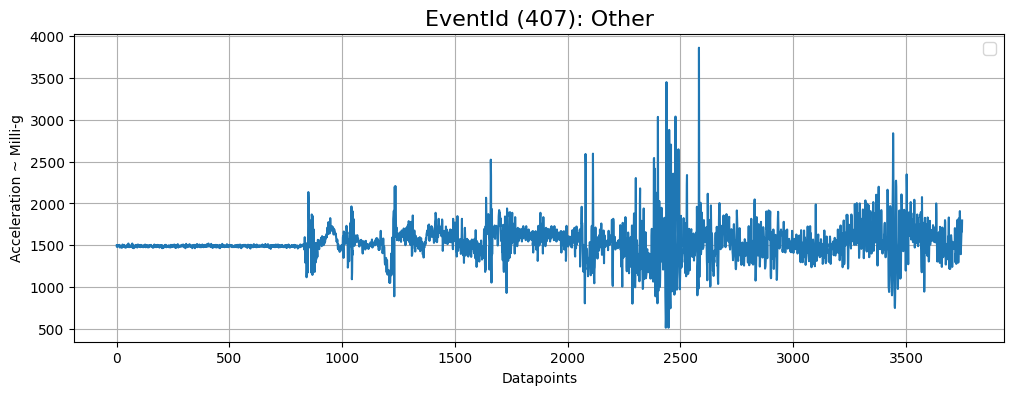

In [113]:
import matplotlib.pyplot as plt

# Example index (choose the index you want to plot, e.g., 0 for the first sample)
index = 0  # Change this index to the desired row in reshaped_data

# Get the eventId and subType from the original DataFrame for this index
event_id = processed_df.loc[index, 'eventId']
sub_type = processed_df.loc[index, 'subType']

# Flatten the first timestep data from reshaped_data
plt.figure(figsize=(12, 4))
plt.title(f"EventId ({event_id}): {sub_type}", fontsize=16)  # Title with eventId and subType

# Plot the first sample's 3750 features
plt.plot(reshaped_data[index].flatten())  # Flatten the array to 1D (3750,)
plt.xlabel("Datapoints")
plt.ylabel("Acceleration ~ Milli-g")
plt.grid(True)
plt.legend(fontsize=12)
plt.show()


In [114]:

# generate n real samples with class labels
def generate_real_samples(ecgsignal,n):
    """Randomly pick n real ECG samples from the dataset and return it together with an array of n ones """
    # generate inputs in [-0.5, 0.5]
    X = ecgsignal[np.random.choice(ecgsignal.shape[0],n)]
    # generate class labels
    y = tf.ones((n, 1))
    return X, y
 
# generate points in latent space as input for the generator
def generate_latent_points(latent_dim, n):
    """Generate random numbers used as input to the generator """
    # generate points in the latent space
    x_in = np.random.randn(latent_dim*n).reshape(n,latent_dim)
    # reshape into a batch of inputs for the network
    return np.expand_dims(x_in,1)
 
def generate_fake_samples(generator, latent_dim, n_samples):
    latent_points = generate_latent_points(latent_dim, n_samples)
    # Reshape latent_points to include the sequence length dimension
    latent_points = latent_points.reshape((n_samples, 1, latent_dim))
    X = generator.predict(latent_points)
    y = np.zeros((n_samples, 1))
    return X, y

def denormalize(fake_data, min_val):
    """
    Denormalize data from [0, 1] (or [-1, 1]) back to the original range.
    """
    if tf.reduce_min(fake_data) < 0:  # If GAN outputs in [-1, 1]
        fake_data = (fake_data + 1) / 2  # Scale to [0, 1]
    return fake_data + min_val



def compare_real_and_gen_ecg(generated_ecg):
    """Plot real and generated Raw data plots side by side"""
    plt.figure(figsize=(24,4))
    plt.subplot(1,2,1)
    plt.title("Generated (fake) RawData", fontsize=16)
    plt.plot(generated_ecg[0,:,0])
    plt.subplot(1,2,2)
    plt.title(f"EventId ({event_id}): {sub_type}", fontsize=16)  # Title with eventId and subType
    plt.plot(reshaped_data[index].flatten())  # Flatten the array to 1D (3750,)
    plt.show()
    

In [115]:
import tensorflow as tf

def _inception_module(
    input_tensor,
    stride=1,
    activation="linear",
    use_bottleneck=True,
    kernel_size=40,
    bottleneck_size=64,  # Increased bottleneck size
    nb_filters=64,       # Increased number of filters
):
    if use_bottleneck and int(input_tensor.shape[-1]) > 1:
        input_inception = tf.keras.layers.Conv1D(
            filters=bottleneck_size,
            kernel_size=1,
            padding="same",
            activation=activation,
            use_bias=False,
        )(input_tensor)
    else:
        input_inception = input_tensor

    kernel_size_s = [kernel_size // (2**i) for i in range(3)]

    conv_list = []
    for i in range(len(kernel_size_s)):
        conv_list.append(
            tf.keras.layers.Conv1D(
                filters=nb_filters,
                kernel_size=kernel_size_s[i],
                strides=stride,
                padding="same",
                activation=activation,
                use_bias=False,
            )(input_inception)
        )

    max_pool_1 = tf.keras.layers.MaxPool1D(pool_size=3, strides=stride, padding="same")(
        input_tensor
    )

    conv_6 = tf.keras.layers.Conv1D(
        filters=nb_filters,
        kernel_size=1,
        padding="same",
        activation=activation,
        use_bias=False,
    )(max_pool_1)

    conv_list.append(conv_6)

    x = tf.keras.layers.Concatenate(axis=2)(conv_list)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Activation(activation="relu")(x)
    return x

def _shortcut_layer(input_tensor, out_tensor):
    shortcut_y = tf.keras.layers.Conv1D(
        filters=int(out_tensor.shape[-1]), kernel_size=1, padding="same", use_bias=False
    )(input_tensor)
    shortcut_y = tf.keras.layers.BatchNormalization()(shortcut_y)

    x = tf.keras.layers.Add()([shortcut_y, out_tensor])
    x = tf.keras.layers.Activation("relu")(x)
    return x

def discriminator(
    input_shape=(3750, 1),
    nb_classes=1,
    depth=3,               # Increased depth
    use_residual=True,
) -> tf.keras.models.Model:
    input_layer = tf.keras.layers.Input(input_shape)

    x = input_layer
    input_res = input_layer

    for d in range(depth):
        x = _inception_module(x)
        if use_residual and d % 3 == 2:
            x = _shortcut_layer(input_res, x)
            input_res = x

    gap_layer = tf.keras.layers.GlobalAveragePooling1D()(x)

    output_layer = tf.keras.layers.Dense(units=nb_classes, activation="sigmoid")(
        gap_layer
    )

    model = tf.keras.models.Model(inputs=input_layer, outputs=output_layer)
    model.compile(
        loss=tf.keras.losses.BinaryCrossentropy(),  # Changed loss function
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.000001),  # Adjusted learning rate
        metrics=[tf.keras.metrics.BinaryAccuracy()],
    )

    return model

desc = discriminator()
print("Discriminator architecture:")
desc.summary()


Discriminator architecture:
Model: "model_4"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_5 (InputLayer)        [(None, 3750, 1)]            0         []                            
                                                                                                  
 max_pooling1d_12 (MaxPooli  (None, 3750, 1)              0         ['input_5[0][0]']             
 ng1D)                                                                                            
                                                                                                  
 conv1d_60 (Conv1D)          (None, 3750, 64)             2560      ['input_5[0][0]']             
                                                                                                  
 conv1d_61 (Conv1D)          (None, 3750, 64)             1280  

In [116]:
desc = discriminator()
print("Discriminator architecture:")
print(desc.summary())

Discriminator architecture:
Model: "model_5"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_6 (InputLayer)        [(None, 3750, 1)]            0         []                            
                                                                                                  
 max_pooling1d_15 (MaxPooli  (None, 3750, 1)              0         ['input_6[0][0]']             
 ng1D)                                                                                            
                                                                                                  
 conv1d_75 (Conv1D)          (None, 3750, 64)             2560      ['input_6[0][0]']             
                                                                                                  
 conv1d_76 (Conv1D)          (None, 3750, 64)             1280  

In [117]:
import tensorflow as tf

def generator():
    model = tf.keras.Sequential()

    # Input layer: 1 timestep with 3750 datapoints per timestep
    model.add(tf.keras.layers.Dense(3750, use_bias=False, input_shape=(1, 3750)))  # 3750 features (1, 3750)
    model.add(tf.keras.layers.BatchNormalization())
    model.add(tf.keras.layers.LeakyReLU(alpha=0.2))  # Adjusted alpha for better gradient flow

    # Reshape layer to maintain the 3750 features as the second dimension (3750, 1)
    model.add(tf.keras.layers.Reshape((3750, 1)))  # Output shape (3750, 1) for 3750 datapoints per timestep
    assert model.output_shape == (None, 3750, 1)  # Output shape: (batch_size, 3750, 1)

    # First Conv1DTranspose layer
    model.add(tf.keras.layers.Conv1DTranspose(128, 5, strides=1, padding='same', use_bias=False))
    assert model.output_shape == (None, 3750, 128)
    model.add(tf.keras.layers.BatchNormalization(momentum=0.8))  # Reduced momentum for more stable updates
    model.add(tf.keras.layers.LeakyReLU(alpha=0.2))  # Consistent alpha adjustment

    # Second Conv1DTranspose layer
    model.add(tf.keras.layers.Conv1DTranspose(64, 5, strides=1, padding='same', use_bias=False))
    assert model.output_shape == (None, 3750, 64)
    model.add(tf.keras.layers.BatchNormalization(momentum=0.8))
    model.add(tf.keras.layers.LeakyReLU(alpha=0.2))

    # Third Conv1DTranspose layer (keeping 3750 timesteps, 1 feature per timestep)
    model.add(tf.keras.layers.Conv1DTranspose(1, 5, strides=1, padding='same', use_bias=False, activation='tanh'))
    assert model.output_shape == (None, 3750, 1)  # Output shape: (batch_size, 3750, 1)

    return model


In [118]:
gen = generator()
print("Generator architecture:")
print(gen.summary())

Generator architecture:
Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_8 (Dense)             (None, 1, 3750)           14062500  
                                                                 
 batch_normalization_30 (Ba  (None, 1, 3750)           15000     
 tchNormalization)                                               
                                                                 
 leaky_re_lu_6 (LeakyReLU)   (None, 1, 3750)           0         
                                                                 
 reshape_2 (Reshape)         (None, 3750, 1)           0         
                                                                 
 conv1d_transpose_6 (Conv1D  (None, 3750, 128)         640       
 Transpose)                                                      
                                                                 
 batch_normalization_31 (Ba  (

Epoch 0/25
1/1 [==============================] - 0s 48ms/step


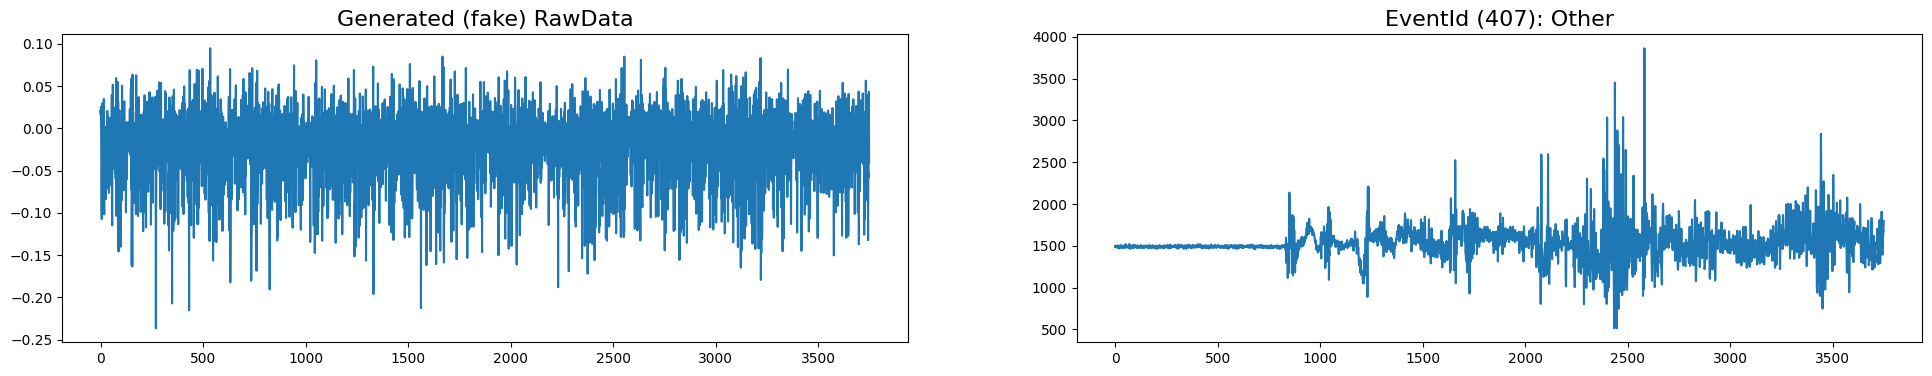

Generator loss: 0.6440663
Discriminator AUROC: 1.0
Discriminator loss: 0.3481046
-------------------
Epoch 1/25
1/1 [==============================] - 0s 60ms/step


KeyboardInterrupt: 

In [119]:

    
import tensorflow as tf
from sklearn.metrics import roc_auc_score

# Define latent dimension and batch size
batch_size = 6
latent_dim = 3750
steps = len(reshaped_data) // batch_size
half_batch = batch_size // 2
epochs = 25

# Define optimizers
init_lr_desc = 0.00002
init_lr_gen = 0.00004
opt_desc = tf.keras.optimizers.Adam(learning_rate=init_lr_desc, beta_1=0.5, beta_2=0.9)
opt_gen = tf.keras.optimizers.Adam(learning_rate=init_lr_gen, beta_1=0.5, beta_2=0.9)

# Training loop
for epoch in range(epochs):
    if epoch % 5 == 0:  # Learning rate adjustment every 5 epochs
        init_lr_desc /= 2
        init_lr_gen /= 2
        opt_desc.lr = init_lr_desc
        opt_gen.lr = init_lr_gen

    accu_loss_gan = []
    accu_loss_desc = []
    print(f"Epoch {epoch}/{epochs}")

    for step in range(steps):
        # Generate real and fake samples
        x_real, y_real = generate_real_samples(reshaped_data, half_batch)
        x_fake, y_fake = generate_fake_samples(gen, latent_dim, half_batch)

        # Ensure x_fake has the same shape as x_real
        if x_fake.shape != x_real.shape:
            x_fake = x_fake.reshape(x_real.shape)

        # Store original x_real for later denormalization comparison
        x_real_original = x_real.copy()

        # Combine real and fake samples
        X_train = np.vstack([x_real, x_fake])
        X_train = np.transpose(X_train, (0, 2, 1))
        y_train = np.vstack([y_real, y_fake])

        # Shuffle the combined data
        p = np.random.permutation(len(y_train))
        X_train, y_train = X_train[p], y_train[p]

        # Update discriminator
        with tf.GradientTape() as tape:
            pred_desc = desc(X_train)
            loss_desc = tf.keras.losses.binary_crossentropy(y_train, pred_desc)
        accu_loss_desc.append(loss_desc)
        grads = tape.gradient(loss_desc, desc.trainable_variables)
        opt_desc.apply_gradients(zip(grads, desc.trainable_variables))

        # Update generator
        with tf.GradientTape() as tape:
            x_latent = generate_latent_points(latent_dim, batch_size)  # Generate latent points
            x_gan = gen(x_latent)  # Generate fake data

            # Denormalize the generated fake data (denormalizing after it's generated)
            x_gan_denormalized = denormalize(x_gan, min_val=0)  # Apply denormalization here

            y_gan = np.ones((batch_size, 1))  # Labels for generated data
            pred_gan = desc(x_gan_denormalized)  # Use the denormalized data in the discriminator
            loss_gan = tf.keras.losses.binary_crossentropy(y_gan, pred_gan)
        accu_loss_gan.append(loss_gan)
        grads = tape.gradient(loss_gan, gen.trainable_variables)
        opt_gen.apply_gradients(zip(grads, gen.trainable_variables))

    # Output statistics every 5 epochs
    if epoch % 2 == 0:
        res = gen(generate_latent_points(latent_dim, 1))  # Generate a new batch
        compare_real_and_gen_ecg(res)
        
    # Calculate AUROC and loss for generator and discriminator
    #print("Generator AUROC:", roc_auc_score(np.concatenate([y_gan.ravel(), np.array([0])]), np.concatenate([np.asarray(pred_gan).ravel(), np.array([0.5])])))

    # Calculate AUROC and loss for discriminator
    print("Generator loss:", np.mean(np.asarray(accu_loss_gan)))
    print("Discriminator AUROC:", roc_auc_score(y_train.ravel(), np.asarray(pred_desc).ravel()))
    print("Discriminator loss:", np.mean(np.asarray(accu_loss_desc)))
    print("-------------------")